In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial'
from scipy.stats import pearsonr
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm, LinearSegmentedColormap

In [2]:
df = pd.read_csv('../data/kodama-gwas_plink_common_bilirubin_gwas_comparison_chr11.tsv', sep='\t')
df

,ID,AF,kodama-gwas_beta,kodama-gwas_se,kodama-gwas_z,plink_beta,plink_se,plink_z,plink-qtr_beta,plink-qtr_se,plink-qtr_z
0,11:179626:T:C,0.071044,-0.003545,0.006551,-0.541129,-0.003430,0.006634,-0.517011,-0.003420,0.006624,-0.516323
1,11:185327:A:G,0.053946,0.002957,0.007461,0.396270,0.003388,0.007516,0.450822,0.003370,0.007494,0.449664
2,11:185388:T:A,0.193592,-0.012891,0.004297,-2.999766,-0.012901,0.004304,-2.997398,-0.012562,0.004247,-2.958205
3,11:185730:G:A,0.054100,0.003100,0.007452,0.415971,0.003536,0.007511,0.470834,0.003517,0.007490,0.469638
4,11:185879:C:T,0.086670,-0.016994,0.006029,-2.818581,-0.016835,0.006020,-2.796476,-0.016438,0.005948,-2.763649
...,...,...,...,...,...,...,...,...,...,...,...
486680,11:135075628:G:A,0.057226,-0.004680,0.007265,-0.644236,-0.004834,0.007276,-0.664359,-0.004779,0.007233,-0.660649
486681,11:135075815:G:T,0.082408,0.002937,0.006151,0.477395,0.002658,0.006150,0.432131,0.002635,0.006123,0.430298
486682,11:135075816:A:G,0.154034,-0.003768,0.004689,-0.803472,-0.003550,0.004687,-0.757365,-0.003488,0.004646,-0.750816
486683,11:135075871:G:A,0.057287,-0.004093,0.007262,-0.563568,-0.004239,0.007269,-0.583246,-0.004191,0.007226,-0.579958


In [ ]:
gridsize=70

names = {
    'kodama-gwas': 'kodama-gwas',
    'kodama-gwas-rv': 'kodama-gwas-rv',
    'kodama-gwas-rac': 'kodama-gwas-rv',
    'plink-qtr': 'PLINK 2.0 qt-residualize',
    'plink': 'PLINK 2.0',
}

colors = {
    'kodama-gwas': '#56C1FF', # blue
    'kodama-gwas-rv': '#A8C256', # green
    'kodama-gwas-rac': '#A8C256', # green
    'plink': '#E9B824', # yellow,
    'plink-qtr': '#e67487', # pink
}

def make_cmap(light_color, bright_color, name='custom'):
    """Create a colormap from light tint to bright saturated color."""
    return LinearSegmentedColormap.from_list(name, ['#ffffff', light_color, bright_color])                                    
                                                                                                                                   
cmaps = {                                                                                                                        
    'kodama-gwas': make_cmap('#5ec4ff', '#0066cc', 'blue_cmap'),                                                                 
    'kodama-gwas-rv': make_cmap('#a8c256', '#4a8c00', 'green_cmap'),                                                             
    'kodama-gwas-rac': make_cmap('#a8c256', '#4a8c00', 'green_cmap'),                                                            
    'plink': make_cmap('#f0c020', '#cc8800', 'yellow_cmap'),                                                                     
    'plink-qtr': make_cmap('#e67487', '#c41040', 'pink_cmap'),                                                                   
}

stat_map = {
    'z': 'z-score',
    'beta': 'beta',
    'se': 'SE'   
}

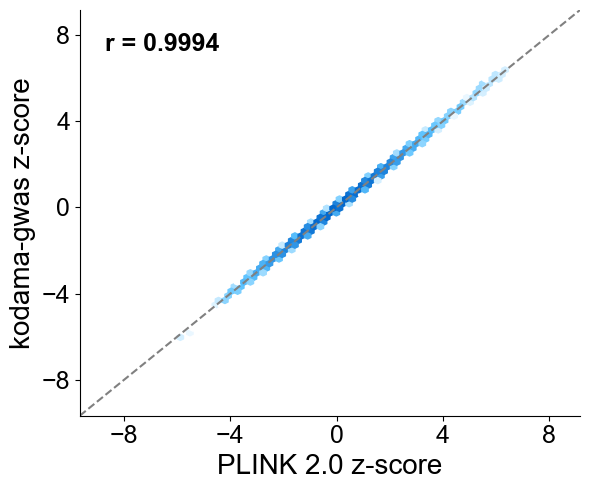

In [ ]:
stat = 'z'
method1 = 'kodama-gwas'
method2 = 'plink'

fig, ax = plt.subplots(figsize=(6, 5))

y = df[f'{method1}_{stat}']
x = df[f'{method2}_{stat}']

hb = ax.hexbin(x, y, gridsize=gridsize, cmap=cmaps[method1], mincnt=1, norm=LogNorm())

ax.set_ylabel(f'{names[method1]} z-score', fontsize=20)
ax.set_xlabel(f'{names[method2]} z-score', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='grey')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

r, _ = pearsonr(x, y)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.text(0.05, 0.9, f"r = {r:.4f}", transform=ax.transAxes,
        fontsize=18, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv('../data/kodama-gwas-rac_plink_all_bilirubin_gwas_comparison_chr11.tsv', sep='\t')
df

,ID,AF,A1FREQ,kodama-gwas-rac_beta,kodama-gwas-rac_se,kodama-gwas-rac_z,plink_beta,plink_se,plink_z,plink-qtr_beta,plink-qtr_se,plink-qtr_z
0,11:103091:G:A,0.000006,0.000005,0.228950,0.680111,0.336636,0.228905,0.680054,0.336598,0.228709,0.679674,0.336498
1,11:103131:G:A,0.000009,0.000008,0.219289,0.447826,0.489675,0.203257,0.430738,0.471881,0.202485,0.429863,0.471045
2,11:103150:G:A,0.000034,0.000035,0.356490,0.254906,1.398516,0.338785,0.248474,1.363463,0.338085,0.248185,1.362230
3,11:103160:TTAAAA:T,0.000102,0.000118,-0.012867,0.141793,-0.090747,-0.012539,0.140294,-0.089374,-0.012528,0.140215,-0.089348
4,11:103168:A:G,0.000006,0.000005,0.705038,0.679902,1.036969,0.704842,0.679833,1.036787,0.704690,0.679672,1.036809
...,...,...,...,...,...,...,...,...,...,...,...,...
29535681,11:135076570:GT:G,0.000918,0.000960,0.031460,0.052545,0.598730,0.032017,0.052972,0.604423,0.032007,0.052956,0.604399
29535682,11:135076576:G:C,0.000194,0.000190,0.163901,0.111537,1.469483,0.162477,0.111043,1.463190,0.162412,0.111007,1.463079
29535683,11:135076578:T:C,0.000176,0.000193,0.019013,0.119330,0.159330,0.020395,0.123291,0.165425,0.020334,0.123089,0.165196
29535684,11:135076584:T:A,0.000545,0.000558,-0.046138,0.068064,-0.677865,-0.045391,0.067514,-0.672324,-0.045377,0.067495,-0.672307


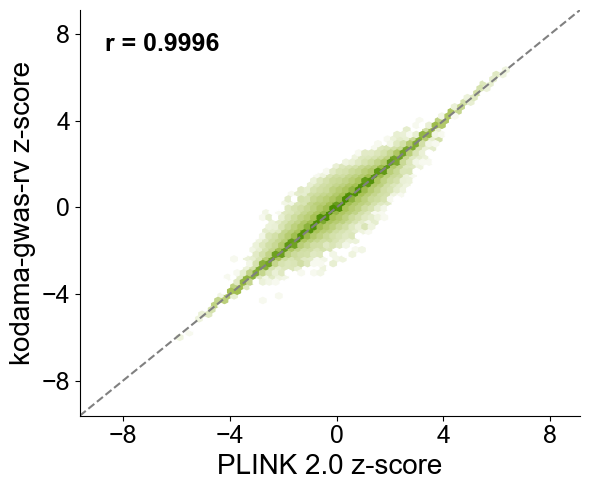

In [ ]:
stat = 'z'
method1 = 'kodama-gwas-rac'
method2 = 'plink'

fig, ax = plt.subplots(figsize=(6, 5))

y = df[f'{method1}_{stat}']
x = df[f'{method2}_{stat}']

hb = ax.hexbin(x, y, gridsize=gridsize, cmap=cmaps[method1], mincnt=1, norm=LogNorm())

ax.set_ylabel(f'{names[method1]} z-score', fontsize=20)
ax.set_xlabel(f'{names[method2]} z-score', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='grey')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

r, _ = pearsonr(x, y)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.text(0.05, 0.9, f"r = {r:.4f}", transform=ax.transAxes,
        fontsize=18, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


plt.tight_layout()
plt.show()